<a href="https://colab.research.google.com/github/harika-1296/SCT_ML_01/blob/main/HOUSE_PRICE_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORTING LIBRARIES AND DATASET

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset = pd.read_excel("HousePricePrediction.xlsx")

print(dataset.head(5))

   Id  MSSubClass MSZoning  LotArea LotConfig BldgType  OverallCond  \
0   0          60       RL     8450    Inside     1Fam            5   
1   1          20       RL     9600       FR2     1Fam            8   
2   2          60       RL    11250    Inside     1Fam            5   
3   3          70       RL     9550    Corner     1Fam            5   
4   4          60       RL    14260       FR2     1Fam            5   

   YearBuilt  YearRemodAdd Exterior1st  BsmtFinSF2  TotalBsmtSF  SalePrice  
0       2003          2003     VinylSd         0.0        856.0   208500.0  
1       1976          1976     MetalSd         0.0       1262.0   181500.0  
2       2001          2002     VinylSd         0.0        920.0   223500.0  
3       1915          1970     Wd Sdng         0.0        756.0   140000.0  
4       2000          2000     VinylSd         0.0       1145.0   250000.0  


In [2]:
dataset.shape

(2919, 13)

DATA PREPROCESSING

In [3]:
object_cols = dataset.select_dtypes(include=['object']).columns
print("Categorical variables:", len(object_cols))

int_ = dataset.select_dtypes(include=['int64']).columns
print("Integer variables:", len(int_))

fl_cols = dataset.select_dtypes(include=['float64']).columns
print("Float variables:", len(fl_cols))

Categorical variables: 4
Integer variables: 6
Float variables: 3


EXPLORATORY DATA ANALYSIS

Heatmap saved as correlation_heatmap.png


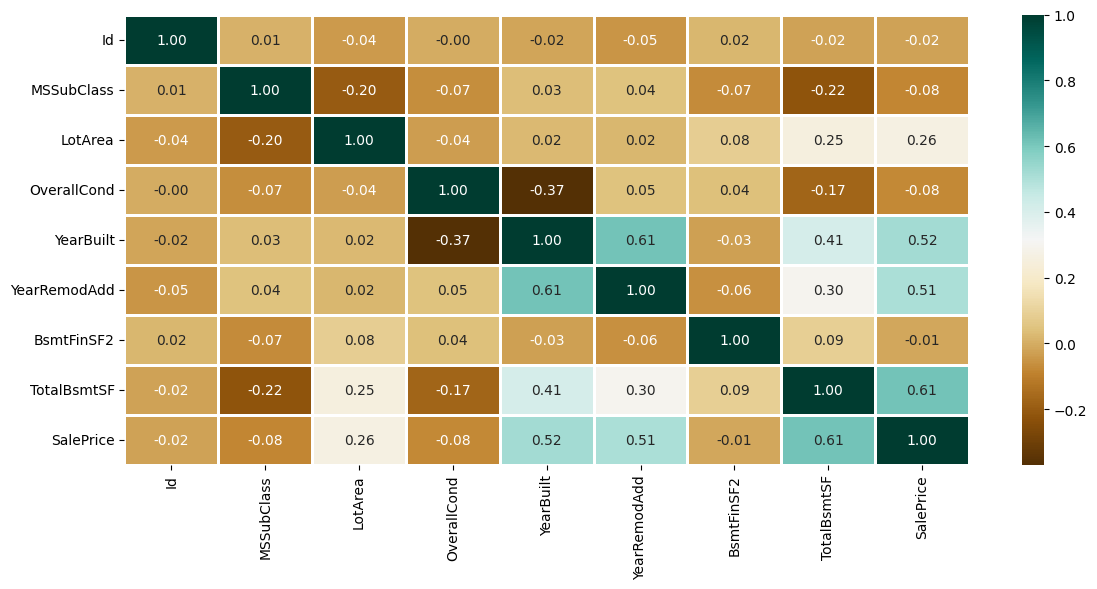

In [4]:
numerical_dataset=dataset.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(12,6))
sns.heatmap(numerical_dataset.corr(),cmap='BrBG',fmt='.2f',linewidths=2,annot=True)
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
print("Heatmap saved as correlation_heatmap.png")

<Axes: title={'center': 'No. Unique values of Categorical Features'}, xlabel='None'>

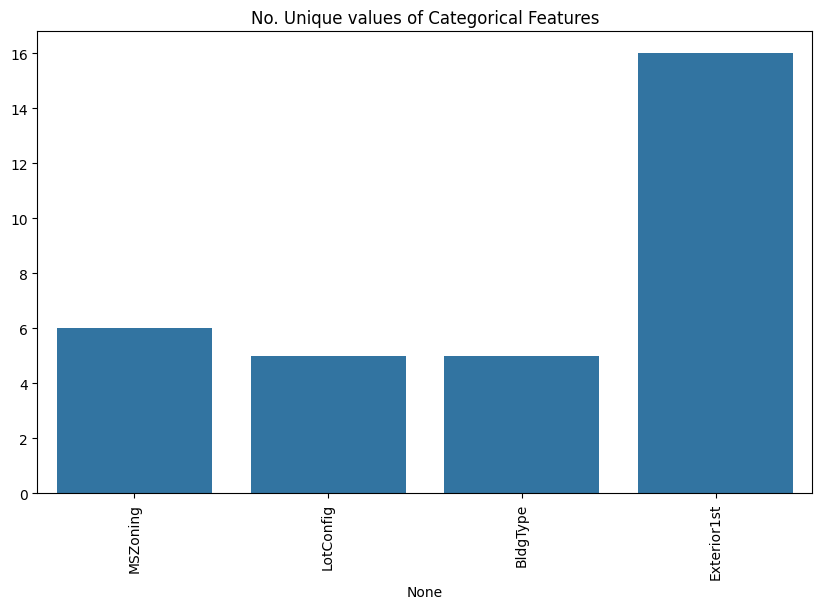

In [5]:
unique_values = []
for col in object_cols:
  unique_values.append(dataset[col].unique().size)
plt.figure(figsize=(10,6))
plt.title('No. Unique values of Categorical Features')
plt.xticks(rotation=90)
sns.barplot(x=object_cols,y=unique_values)

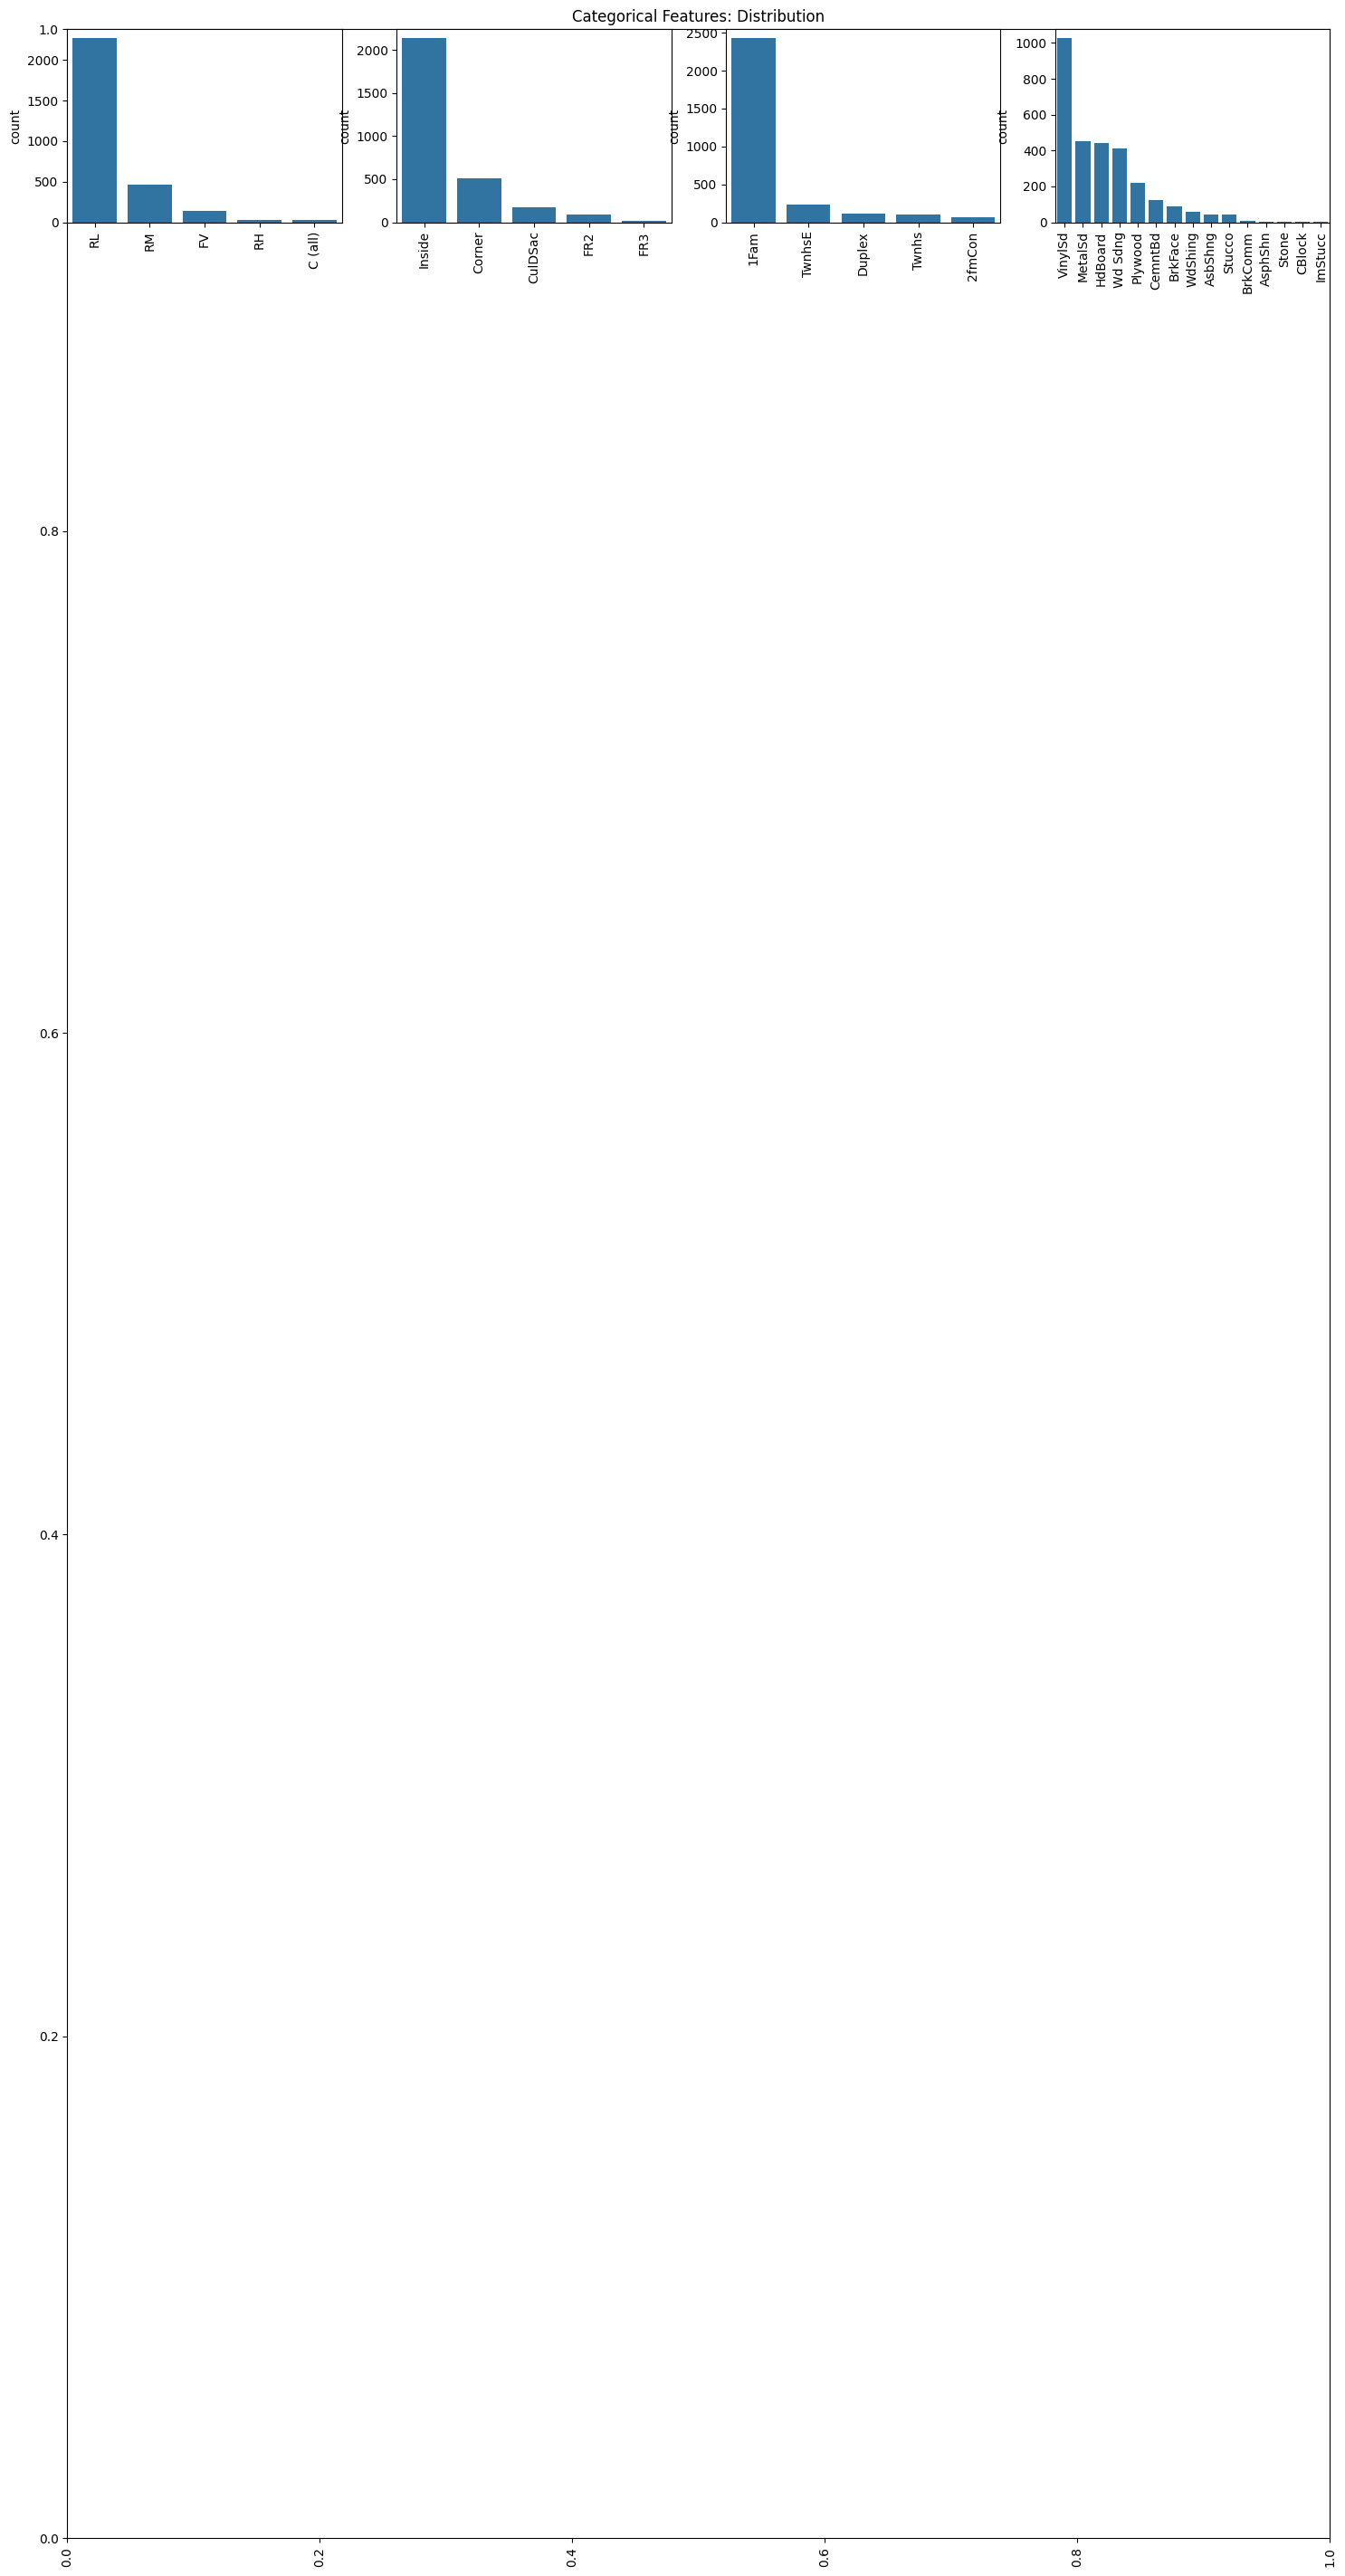

In [6]:
plt.figure(figsize=(18, 36))
plt.title('Categorical Features: Distribution')
plt.xticks(rotation=90)
index = 1

for col in object_cols:
    y = dataset[col].value_counts()
    plt.subplot(11, 4, index)
    plt.xticks(rotation=90)
    sns.barplot(x=list(y.index), y=y)
    index += 1

DATA CLEANING

In [7]:
dataset.drop(['Id'],
             axis=1,
             inplace=True)

In [8]:
dataset['SalePrice'] = dataset['SalePrice'].fillna(
  dataset['SalePrice'].mean())

In [9]:
new_dataset = dataset.dropna()

In [10]:
new_dataset.isnull().sum()

,0
MSSubClass,0
MSZoning,0
LotArea,0
LotConfig,0
BldgType,0
OverallCond,0
YearBuilt,0
YearRemodAdd,0
Exterior1st,0
BsmtFinSF2,0


ONE HOT ENCODER

In [11]:
from sklearn.preprocessing import OneHotEncoder

s = (new_dataset.dtypes == 'object')
object_cols = list(s[s].index)
print("Categorical variables:")
print(object_cols)
print('No. of. categorical features: ',
      len(object_cols))

Categorical variables:
['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']
No. of. categorical features:  4


In [12]:
OH_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
OH_cols = pd.DataFrame(OH_encoder.fit_transform(new_dataset[object_cols]))
OH_cols.index = new_dataset.index
OH_cols.columns = OH_encoder.get_feature_names_out()
df_final = new_dataset.drop(object_cols, axis=1)
df_final = pd.concat([df_final, OH_cols], axis=1)

SPLITTING DATASET INTO TRAINING AND TESTING

In [13]:
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

X = df_final.drop(['SalePrice'], axis=1)
Y = df_final['SalePrice']

X_train, X_valid, Y_train, Y_valid = train_test_split(
    X, Y, train_size=0.8, test_size=0.2, random_state=0)

MODEL TRAINING AND ACCURACY (SVM,RFR,LR)
1.SVM - SUPPORT VECTOR MACHINE

In [16]:
from sklearn import svm
from sklearn.svm import SVC
from sklearn.metrics import mean_absolute_percentage_error

model_SVR = svm.SVR()
model_SVR.fit(X_train,Y_train)
Y_pred = model_SVR.predict(X_valid)

print(mean_absolute_percentage_error(Y_valid, Y_pred))

0.1870512931870423


2. RFR - RANDOM FOREST REGRESSION

UPGRADING FROM CGPT

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)
rf.fit(X_train, Y_train)


RandomForestRegressor(max_depth=10, n_estimators=300, random_state=42)

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

3. LR - LINEAR REGRESSION

In [20]:
from sklearn.linear_model import LinearRegression

model_LR = LinearRegression()
model_LR.fit(X_train, Y_train)
Y_pred = model_LR.predict(X_valid)

print(mean_absolute_percentage_error(Y_valid, Y_pred))

0.197368549109981


In [21]:
print(Y_pred)


[168500.24776946 180809.2109079  183021.60052384 185638.12132612
 179365.61201855 179733.8604154  178467.27506293 172158.13906526
 175871.75683502 181301.0763309  173565.75670575 183244.93706266
 176037.10700075 177301.35888756 180351.35772887 175797.84789562
 178210.17884063 181830.76844482 182769.20945787 187466.85376232
 180920.83585185 174836.67220849 186179.06158834 177359.92690919
 181035.63768869 171850.46381982 176677.12257835 179119.06304946
 204869.38514662 173770.36123839 171638.98273969 178930.30693551
 183729.23032728 180153.60870854 186876.93882887 180126.12629012
 176624.33476076 180295.66912651 179240.45751801 172010.32607244
 174037.74458186 182737.90893994 185973.33867465 182448.75821054
 182853.57205052 181854.48726291 190091.70746975 181152.80011903
 177609.69174685 183583.16533781 178134.82512259 179619.31143763
 171603.51644071 178167.70312185 180823.44063819 181008.47697497
 187914.28585073 181873.82784282 178827.42872083 180732.86993235
 183342.83125511 177666.2

In [22]:
import pandas as pd

results = pd.DataFrame({
    "Actual Price": Y_valid,
    "Predicted Price": Y_pred
})

print(results.head(10))

      Actual Price  Predicted Price
1728  180921.19589    168500.247769
2689  180921.19589    180809.210908
1151  149900.00000    183021.600524
2762  180921.19589    185638.121326
1180  250000.00000    179365.612019
2223  180921.19589    179733.860415
553   108000.00000    178467.275063
104   169500.00000    172158.139065
1190  168000.00000    175871.756835
2308  180921.19589    181301.076331


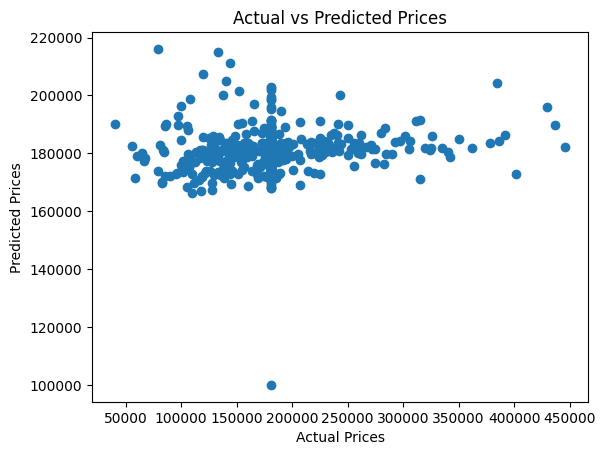

In [23]:
import matplotlib.pyplot as plt

plt.scatter(Y_valid, Y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()


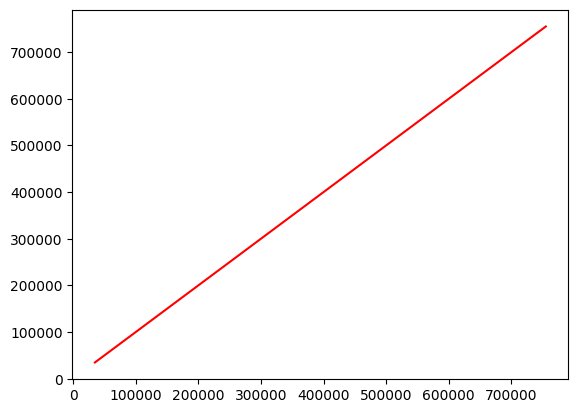

In [24]:
plt.plot([min(y_test), max(y_test)],
         [min(y_test), max(y_test)],
         color='red')


In [25]:
from sklearn.metrics import r2_score

# The variables y_pred_lr, y_pred_rf, y_pred_svm are not defined in the kernel.
# To resolve this, ensure predictions from each model are stored in distinct variables,
# for example, in their respective training cells:
# For SVM (cell qVxmJ5ARucg0): y_pred_svm = model_SVR.predict(X_valid)
# For RFR (cell 8S1l6aPUvqmy): y_pred_rf = model_RFR.predict(X_valid)
# For LR (cell O6SPyt1HwILe): y_pred_lr = model_LR.predict(X_valid)

# Also, note that Y_pred was calculated on X_valid, but this cell attempts to use y_test.
# To maintain consistency, we will use Y_valid for actual values in the R2 score for Linear Regression,
# as Y_pred (current value from Linear Regression) was generated using X_valid.

# Calculate R2 for Linear Regression using available variables (Y_valid and Y_pred)
print("Linear Regression R2:", r2_score(Y_valid, Y_pred))

# The following lines are commented out because y_pred_rf and y_pred_svm are not defined.
# To enable them, modify the model training cells to store predictions in these variables.
# print("Random Forest R2:", r2_score(Y_valid, y_pred_rf))
# print("SVM R2:", r2_score(Y_valid, y_pred_svm))

Linear Regression R2: 0.014992203668954263


In [26]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("New R2:", r2_score(y_test, y_pred))


New R2: 0.39270188882379164


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


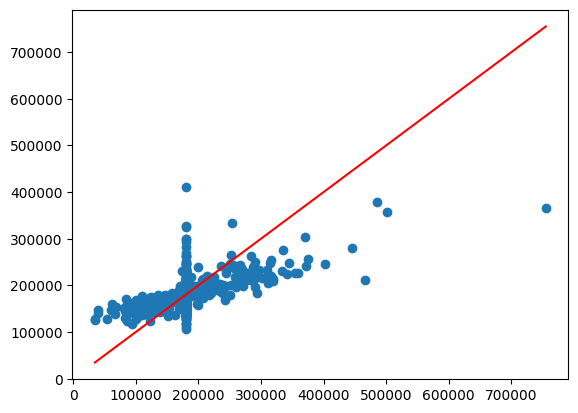

In [28]:
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)],
         [min(y_test), max(y_test)],
         color='red')
plt.show()


In [29]:
import numpy as np

df_final = df_final[df_final['SalePrice'] < np.percentile(df_final['SalePrice'], 95)]

In [30]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=800,        # more trees
    learning_rate=0.03,      # slower learning
    max_depth=4,             # slightly deeper trees
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

gbr.fit(X_train, y_train)

y_pred = gbr.predict(X_test)

print("Improved GBR R2:", r2_score(y_test, y_pred))


Improved GBR R2: 0.3413709083360824


In [31]:
import numpy as np

y_train_log = np.log(y_train)
y_test_log = np.log(y_test)


In [32]:
gbr.fit(X_train, y_train_log)

y_pred_log = gbr.predict(X_test)

# Convert back
y_pred = np.exp(y_pred_log)

print("Log GBR R2:", r2_score(y_test, y_pred))


Log GBR R2: 0.298781500819292


In [33]:
df_final = df_final[df_final['SalePrice'] < df_final['SalePrice'].quantile(0.95)]

In [34]:
from sklearn.metrics import r2_score

# Linear Regression predictions are in Y_pred (from cell O6SPyt1HwILe) and were made on X_valid.
print("Linear Regression R2:", r2_score(Y_valid, Y_pred))

# Log-transformed Gradient Boosting predictions are in y_pred (from cell QRPABTXTc1XW) and were made on X_test.
print("Gradient Boosting R2:", r2_score(y_test, y_pred))

# The following prediction variables are not defined in the current kernel state.
# To calculate their R2 scores, ensure their predictions are stored in unique variables
# in their respective model training cells.
# print("SVM R2:", r2_score(Y_valid, y_pred_svm))
# print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Linear Regression R2: 0.014992203668954263
Gradient Boosting R2: 0.298781500819292


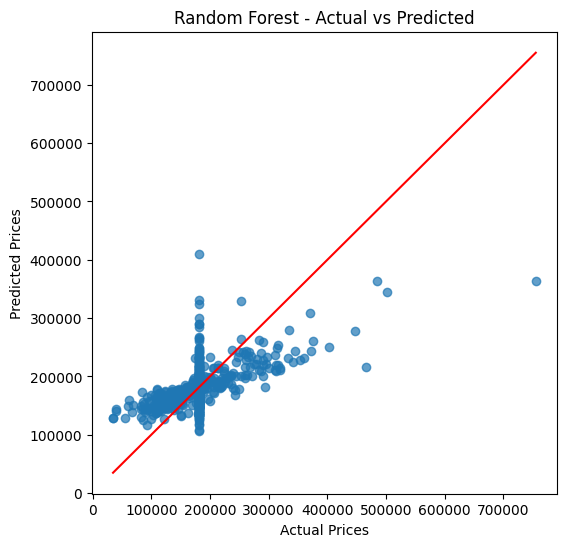

In [37]:
from sklearn.ensemble import RandomForestRegressor

# Define and train the Random Forest model to get y_pred_rf
# Using the currently available X_train, y_train, X_test, y_test
rf = RandomForestRegressor(
    n_estimators=1000,
    max_depth=None,
    min_samples_split=3,
    min_samples_leaf=1,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.7)
plt.plot([min(y_test), max(y_test)],
         [min(y_test), max(y_test)], color='red')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Random Forest - Actual vs Predicted")
plt.show()

In [38]:
rf = RandomForestRegressor(
    n_estimators=1000,
    max_depth=None,
    min_samples_split=3,
    min_samples_leaf=1,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Final RF R2:", r2_score(y_test, y_pred_rf))


Final RF R2: 0.39319864834231566


In [39]:
plt.show()

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))   # makes graph bigger


<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

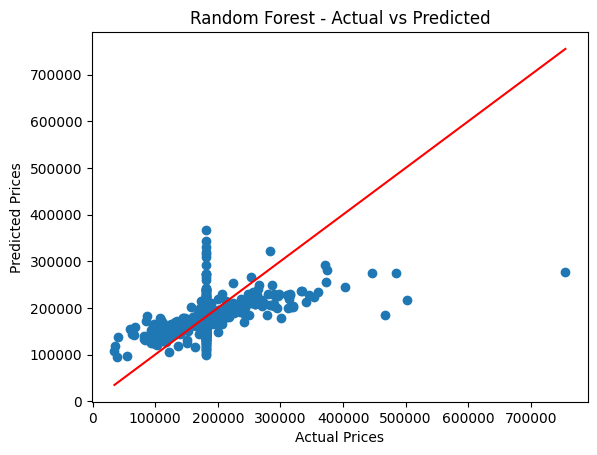

In [41]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Random Forest - Actual vs Predicted")

plt.show()


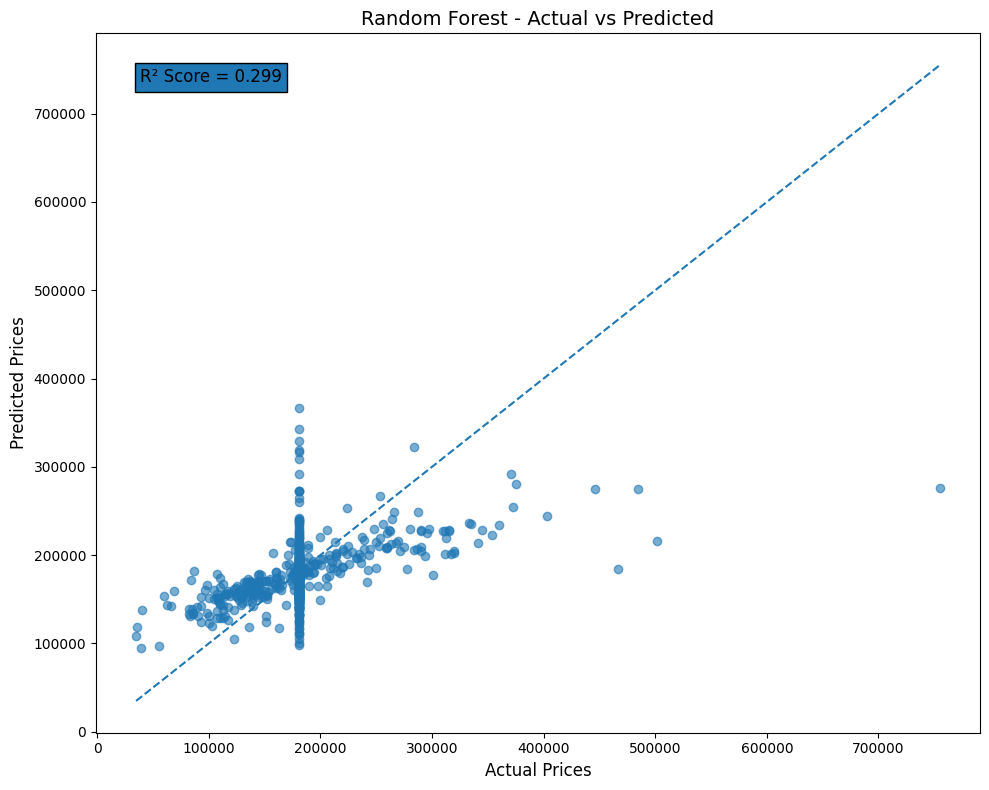

In [42]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

# Calculate R2
r2 = r2_score(y_test, y_pred)

plt.figure(figsize=(10, 8))

# Scatter plot
plt.scatter(y_test, y_pred, alpha=0.6)

# Ideal prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Actual Prices", fontsize=12)
plt.ylabel("Predicted Prices", fontsize=12)
plt.title("Random Forest - Actual vs Predicted", fontsize=14)

# Add R2 inside graph
plt.text(
    0.05,
    0.95,
    f'R² Score = {r2:.3f}',
    transform=plt.gca().transAxes,
    verticalalignment='top',
    fontsize=12,
    bbox=dict()
)

plt.tight_layout()
plt.show()


(0.0, 400000.0)

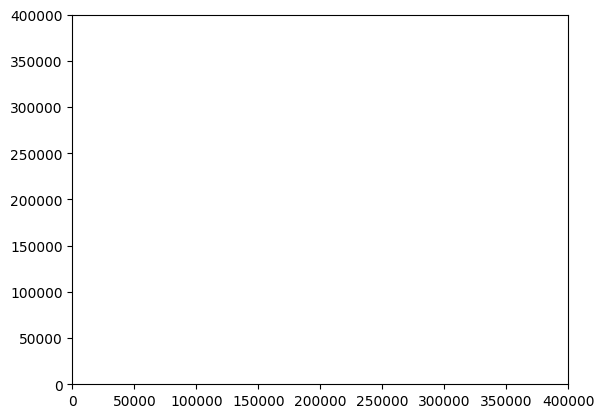

In [43]:
plt.xlim(0, 400000)
plt.ylim(0, 400000)


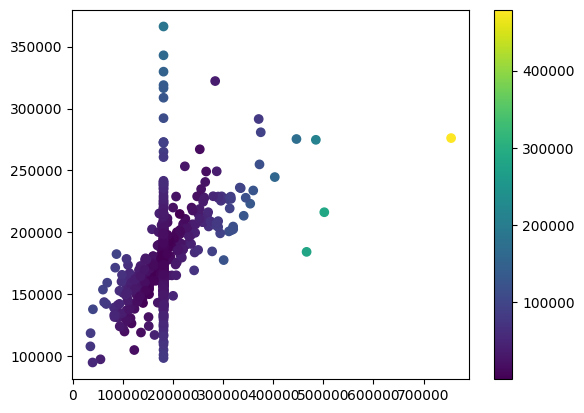

In [44]:
errors = abs(y_test - y_pred)
plt.scatter(y_test, y_pred, c=errors)
plt.colorbar()


In [45]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
rf.fit(X_train, y_train)


RandomForestRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=500, random_state=42)

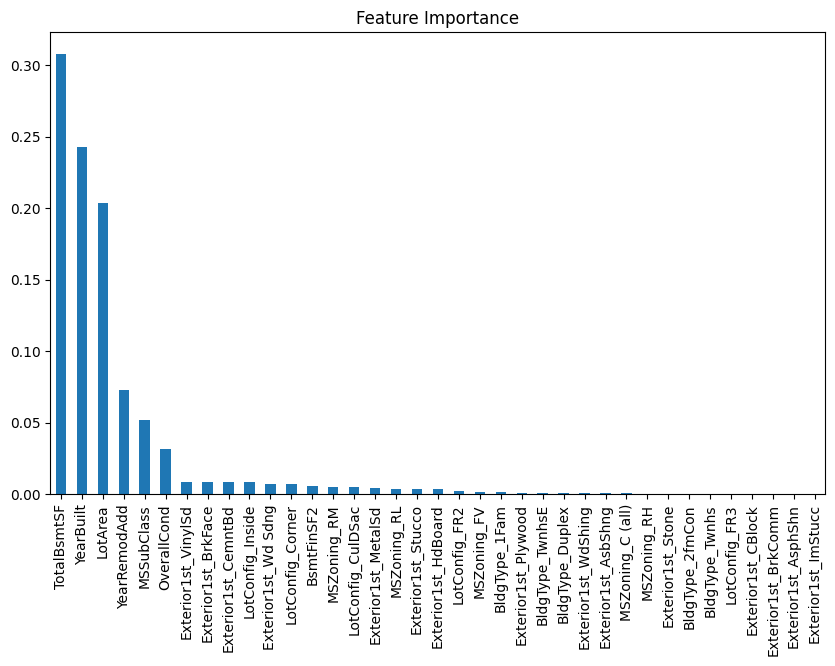

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.plot(kind='bar')
plt.title("Feature Importance")
plt.show()